# 0. Language Model Training

In this introductory section I want to briefly mention about the main phases of LM training, as this notebook is going to cover (2,3):

**Pretraining**
- Foundation building on massive text corpora
- Learns language patterns, facts, and reasoning capabilities
- Creates a general-purpose language model

**Supervised Fine-Tuning (SFT)**
- Instruction-tuning on curated (prompt, response) pairs
- Teaches model to follow instructions and adopt desired formats
- Uses high-quality human demonstrations

**Reinforcement Learning from Human Feedback (RLHF)**
- Alignment with human preferences using reward models
- Optimizes for helpfulness, harmlessness, and quality
- Balances performance with safety constraints

---
*Note: LoRA/QLoRA is strongly advised for efficient fine-tuning*

# 1. Reward Model

In this section, we train a **reward model** to evaluate the quality or relevance of generated content.  
We skip the earlier stages of the LLM pipeline — **(1) pretraining** and **(2) supervised fine-tuning** — and start from an already **instruction-tuned model**.

---

### Objective

The goal is to learn a reward function  
$$
r_\phi(x, y)
$$  
that assigns a scalar value to a model output $y$ given an input $x$.  

Here, $x \sim \mathcal{D}$ represents a sample drawn from the data distribution,  and $ y \sim \pi_\theta(y \mid x) $ is a response generated by the language model.
This value represents how *preferred* or *relevant* the output is, acting as a proxy for human feedback.


### Approach

A common method is to frame reward modeling as a **regression task**, where the model predicts an **unbounded scalar reward**.

We use a pretrained language model $\pi_\theta(y \mid x)$ and attach a final linear layer with a single neuron, which will be trained to output the predicted reward value $r_\phi(x, y)$ from the positive and negative prompts in the prompt database $\mathcal{D}$.

---
### Training the Reward Model

The reward model $r_\phi(x, y)$ is trained to predict human (or synthetic) preferences over pairs of model outputs.

#### Preference-Based Objective

Given a prompt $x$ and two candidate responses $(y^+, y^-)$,  
where $y^+$ is preferred over $y^-$ according to human feedback,  
the model should assign a higher reward to $y^+$:

$$
r_\phi(x, y^+) > r_\phi(x, y^-)
$$

To enforce this, we use a **pairwise logistic loss** (used in RLHF, e.g. in InstructGPT):

$$
\mathcal{L}_{\text{RM}}(\phi)
= - \mathbb{E}_{(x, y^+, y^-) \sim \mathcal{D}}
  \left[
    \log \sigma\!\left(r_\phi(x, y^+) - r_\phi(x, y^-)\right)
  \right]
$$

where $\sigma(\cdot)$ is the sigmoid function:
$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

This encourages the model to assign a higher score to the preferred completion.

---

#### Intuition

- If $r_\phi(x, y^+) \gg r_\phi(x, y^-)$,  
  then $\sigma(r_\phi(x, y^+) - r_\phi(x, y^-)) \approx 1$,  
  and the loss is small.  
- If the model ranks them incorrectly, the loss is large.  

---

#### Alternative (Regression) Objective

If explicit preference pairs are unavailable,  
the reward model can also be trained via regression to approximate scalar feedback values:

$$
\mathcal{L}_{\text{reg}}(\phi)
= \mathbb{E}_{(x, y, R) \sim \mathcal{D}}
  \left[ (r_\phi(x, y) - R)^2 \right]
$$

---

We will use pairwise as the training objective rather than the regression training loss.



In [ ]:

!pip install wordfreq
!pip install textstats
!pip install trl

# Basic modules
import json
import pandas as pd
import math
import matplotlib.pyplot as plt
import os
import re
from typing import List, Union, Callable, Dict, Optional

# NLP related libraries
import statistics
import spacy
import wordfreq
import textstats

# Transformer & ML related libraries
import transformers
from transformers import AutoModelForSequenceClassification, AutoModelForCausalLM
from transformers import AutoTokenizer, TrainingArguments, default_data_collator
from transformers import GenerationConfig
from trl import RewardConfig, RewardTrainer
from peft import LoraConfig
import torch
from datasets import load_dataset, DatasetDict, Dataset

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 16.6 MB/s eta 0:00:00


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 11.3 MB/s eta 0:00:00


To oversimply the life-cycle of RLHF, we will use TRL hugging face library to see how this can performed easily with a high level of abstraction thanks to this library

### Plotting utilities & Data Processing

In [2]:
def ema(series: pd.Series, alpha: float = 0.05) -> pd.Series:
    """Exponential moving average smoothing."""
    out = []
    prev = None
    for v in series:
        if pd.isna(v):
            out.append(v)
            continue
        prev = v if prev is None else alpha * v + (1 - alpha) * prev
        out.append(prev)
    return pd.Series(out, index=series.index)

def get_log_dataframe(trainer) -> pd.DataFrame:
    """Extract logs from a trainer-like object into a DataFrame with a step column."""
    history = getattr(getattr(trainer, "state", None), "log_history", None) or getattr(trainer, "log_history", None)
    if not history:
        raise ValueError("No log history found in trainer.")
    df = pd.DataFrame(history)
    if "step" not in df.columns:
        df["step"] = range(len(df))
    return df.sort_values("step").reset_index(drop=True)

def _save_plot(fig, save_dir: str, run_name: str, plot_name: str):
    """Save both PNG and PDF of a matplotlib figure."""
    os.makedirs(save_dir, exist_ok=True)
    png_path = os.path.join(save_dir, f"{run_name}_{plot_name}.png")
    pdf_path = os.path.join(save_dir, f"{run_name}_{plot_name}.pdf")
    fig.tight_layout()
    fig.savefig(png_path, dpi=200)
    fig.savefig(pdf_path)
    plt.show()
    print(f"Saved: {png_path} and {pdf_path}")

def plot_training_metrics(df: pd.DataFrame, run_name: str, save_dir="plots", smooth_alpha=0.07):
    # --- LOSS ---
    loss_col = next((c for c in ["loss","training_loss","total_loss"] if c in df.columns), None)
    if loss_col:
        y_sm = ema(pd.to_numeric(df[loss_col], errors="coerce"), alpha=smooth_alpha)
        fig, ax = plt.subplots(figsize=(8,4))
        ax.plot(df["step"], y_sm, color="tab:red", label=loss_col)
        ax.set_xlabel("step"); ax.set_ylabel("Loss")
        ax.set_title(f"{run_name} — Training Loss")
        ax.grid(True, alpha=0.3)
        ax.legend()
        _save_plot(fig, save_dir, run_name, "loss")

    # --- REWARDS: chosen & rejected ---
    reward_cols = [c for c in df.columns if c in ["rewards/chosen","rewards/rejected"]]
    if reward_cols:
        fig, ax = plt.subplots(figsize=(8,4))
        if "rewards/chosen" in reward_cols:
            ax.plot(df["step"], ema(pd.to_numeric(df["rewards/chosen"], errors="coerce"), alpha=smooth_alpha),
                    label="rewards/chosen", color="tab:green")
        if "rewards/rejected" in reward_cols:
            ax.plot(df["step"], ema(pd.to_numeric(df["rewards/rejected"], errors="coerce"), alpha=smooth_alpha),
                    label="rewards/rejected", color="tab:red")
        # optional: diff
        if all(c in df.columns for c in ["rewards/chosen","rewards/rejected"]):
            diff = df["rewards/chosen"] - df["rewards/rejected"]
            ax.plot(df["step"], ema(diff, alpha=smooth_alpha), label="rewards/diff", color="tab:blue", linestyle="--")
        ax.set_xlabel("step"); ax.set_ylabel("Reward")
        ax.set_title(f"{run_name} — Reward Metrics")
        ax.grid(True, alpha=0.3)
        ax.legend()
        _save_plot(fig, save_dir, run_name, "reward")
    else:
        print(f"[{run_name}] No chosen/rejected reward columns found; skipping reward plot.")

# -------------------------
# Example usage
# -------------------------

In [3]:
SEED = 42
SHUFFLE_SEED = 42
HF_DATASET_ID = "eZWALT/rlhf_reward_data_raw"
HUB_REPO_ID = "eZWALT/rlhf_reward_splits_raw"
PUSH_TO_HUB = False


SEED = 42
SHUFFLE_SEED = 42
ds = load_dataset(HF_DATASET_ID, split="train")


# 2) shuffle then split to 80/10/10
# First shuffle the entire dataset (important to get a random split)
ds = ds.shuffle(seed=SHUFFLE_SEED)

# Split 80/20 (train / rest)
train_test = ds.train_test_split(test_size=0.20, seed=SEED)
train_ds = train_test["train"]          # ~80%
rest_ds = train_test["test"]            # ~20%

# Split the rest into half/half -> validation/test = 10% each
val_test = rest_ds.train_test_split(test_size=0.5, seed=SEED)
val_ds = val_test["train"]              # ~10%
test_ds = val_test["test"]              # ~10%

# Put into DatasetDict
dataset_dict = DatasetDict({
    "train": train_ds,
    "validation": val_ds,
    "test": test_ds
})

print(dataset_dict)
print("Train / Val / Test sizes:", len(dataset_dict["train"]), len(dataset_dict["validation"]), len(dataset_dict["test"]))

# 3a) Save locally for later use (optional)
dataset_dict.save_to_disk("../data/hf_rlhf_splits")

# 3b) Push the new split dataset to the Hub (optional)
if PUSH_TO_HUB:
    dataset_dict.push_to_hub(HUB_REPO_ID, private=True)
    print("Pushed split dataset to hub at:", HUB_REPO_ID)


# Hand written small dataset of prompts to do "gut feeling" quick testing.
test_prompts = [
    "Explain what artificial intelligence is.",
    "What is a convolution in computer vision?",
    "What is a token in natural language processing?",
    "Describe the transformer architecture in machine learning.",
    "What is an embedding?",
    "Explain the difference between supervised and unsupervised learning.",

    "Describe how to cook a chicken.",
    "How do i make cookies?",
    "Which are uncommon typical italian dishes?",
    "Tell me about regional dishes from Veneto, Italy",

    "Explain the biomechanical principles of proper tongue posture.",
    "What is the evidence for dietary influences on craniofacial development?",
    "Describe the relationship between nasal breathing and maxillary growth.",
    "What are the physiological mechanisms behind mewing?",

    "Explain the biomechanics of a handstand push-up.",
    "What are the physiological prerequisites for performing a muscle-up?",
    "Describe the motor learning progression for planche mastery.",
    "What distinguishes concentric from eccentric muscle contractions?",
    "Explain the role of leverage in bodyweight exercise difficulty.",

    "List the most protein rich foods",
    "What is your opinion on paleolithic diet from a scientific perspective?",
    "Explain the physiological effects of intermittent fasting.",
]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/382 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/1.01M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1500 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['prompt', 'chosen', 'rejected', 'model'],
        num_rows: 1200
    })
    validation: Dataset({
        features: ['prompt', 'chosen', 'rejected', 'model'],
        num_rows: 150
    })
    test: Dataset({
        features: ['prompt', 'chosen', 'rejected', 'model'],
        num_rows: 150
    })
})
Train / Val / Test sizes: 1200 150 150


Saving the dataset (0/1 shards):   0%|          | 0/1200 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/150 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/150 [00:00<?, ? examples/s]

### Reward Modelling

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    "HuggingFaceTB/SmolLM2-135M-Instruct",
    dtype=torch.bfloat16,
    num_labels=1 # If we ever train the reward model ever again `please use this, it should not have 2 heads that is nonsense
)

# Configuration for the Reward Model training loop
reward_config = RewardConfig(
    remove_unused_columns=False,
    logging_steps=5,
    num_train_epochs=2,
    data_seed=42,
)
# important to include the score head when base model is not a sequence classification model
lora_config = LoraConfig(
    modules_to_save=["score"],
)

processing_class = AutoTokenizer.from_pretrained("HuggingFaceTB/SmolLM2-135M-Instruct")

reward_trainer = RewardTrainer(
    model=model,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    args=reward_config,
    #peft_config=lora_config,
    processing_class=processing_class,
)
reward_trainer.train()

Some weights of LlamaForSequenceClassification were not initialized from the model checkpoint at HuggingFaceTB/SmolLM2-135M-Instruct and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Filtering train >1024 tokens:   0%|          | 0/1200 [00:00<?, ? examples/s]

Filtering eval >1024 tokens:   0%|          | 0/150 [00:00<?, ? examples/s]

Step,Training Loss
5,0.776700
10,0.582400
15,0.591500
20,0.226000
25,0.325100
30,0.157800
35,0.211000
40,0.249000
45,0.126000
50,0.203200


TrainOutput(global_step=300, training_loss=0.14527402885258198, metrics={'train_runtime': 1132.0187, 'train_samples_per_second': 2.118, 'train_steps_per_second': 0.265, 'total_flos': 1463960133149184.0, 'train_loss': 0.14527402885258198, 'epoch': 2.0})

These are excellent results for the reward model. The most critical metric, eval_accuracy of $94.08\%$, means the RM correctly identified the human-preferred response $94.08\%$ of the time on the validation set, confirming it has successfully learned the human preference distribution.

The low eval_loss of $0.1911$ indicates high confidence and accuracy, while the large, positive eval_margin of $5.7688$ shows the RM strongly differentiates good responses from bad ones.

However its notable that the scalar values are weird (mean $-4.06$?)

In [ ]:
metrics = reward_trainer.evaluate()
reward_trainer.log_metrics("eval", metrics)
reward_trainer.save_metrics("eval", metrics)

***** eval metrics *****
  epoch                   =        2.0
  eval_accuracy           =     0.9458
  eval_loss               =     0.1911
  eval_margin             =     5.8014
  eval_max_reward         =     2.2771
  eval_mean_reward        =    -4.0671
  eval_min_reward         =     -9.075
  eval_num_tokens         =   980440.0
  eval_runtime            = 0:00:21.23
  eval_samples_per_second =      7.064
  eval_steps_per_second   =      0.895


In [ ]:
## Push to HuggingFace
repo_name = "SmolLM2-135M-Pedantic-Reward-Model"
#reward_trainer.push_to_hub(repo_name)

model.push_to_hub(repo_name)

README.md: 0.00B [00:00, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...fztazxu/model.safetensors:   0%|          |  599kB /  269MB            

CommitInfo(commit_url='https://huggingface.co/eZWALT/SmolLM2-135M-Pedantic-Reward-Model/commit/5a113e6058a32ba181d4b2af67c1177c785e9fe4', commit_message='Upload LlamaForSequenceClassification', commit_description='', oid='5a113e6058a32ba181d4b2af67c1177c785e9fe4', pr_url=None, repo_url=RepoUrl('https://huggingface.co/eZWALT/SmolLM2-135M-Pedantic-Reward-Model', endpoint='https://huggingface.co', repo_type='model', repo_id='eZWALT/SmolLM2-135M-Pedantic-Reward-Model'), pr_revision=None, pr_num=None)

### Visualize the architechture of the Reward Model

This reward model uses a $30$-layer SmolLM2 transformer architecture with $576$-dimensional token embeddings from a $49152$ vocabulary. The model processes sequences through rotary positional encodings (RoPE) and multi-head attention with $3$ heads using $\text{Attention}(Q,K,V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$, followed by MLP blocks that expand $576→1536$ dimensions with $SiLU$ activation before projecting back. Each layer uses $RMSNorm$ for normalization. The final linear head $\text{Reward} = W \cdot h_{\text{final}}$ converts the last hidden state into a single reward score for RLHF training (that takes an embedding $\mathcal{R}^{576}$ and outputs $2$ values)

There is something inherently weird about the final model having 2 linear heads instead of 1,

In [ ]:
model

LlamaForSequenceClassification(
  (model): LlamaModel(
    (embed_tokens): Embedding(49152, 576, padding_idx=2)
    (layers): ModuleList(
      (0-29): 30 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=576, out_features=576, bias=False)
          (k_proj): Linear(in_features=576, out_features=192, bias=False)
          (v_proj): Linear(in_features=576, out_features=192, bias=False)
          (o_proj): Linear(in_features=576, out_features=576, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=576, out_features=1536, bias=False)
          (up_proj): Linear(in_features=576, out_features=1536, bias=False)
          (down_proj): Linear(in_features=1536, out_features=576, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((576,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((576,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((576,), eps

In [ ]:
tokenizer = processing_class
normal_text = "This is a great movie and I loved every minute of it."
pedantic_text = "This cinematic production constitutes an exemplary fulfillment of its artistic aims, and I found the entire temporal duration of its presentation to be a source of unmitigated positive engagement."

# If you want to use cpu for inference simply put it in a cpu and remove .to(model.device) to avoid offloading
inputs = tokenizer([normal_text, pedantic_text], return_tensors='pt', padding=True, truncation=True).to(model.device)
with torch.no_grad():
    outputs = model(**inputs)
outputs

SequenceClassifierOutputWithPast(loss=None, logits=tensor([[-1.9141],
        [-0.8320]], device='cuda:0'), past_key_values=DynamicCache(layers=[DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer]), hidden_states=None, attentions=None)

# 2. Reinforcement Learning from Human Feedback (RLHF)
After training our reward model, we are going to proceed into this preference alingment procedure by using this reward model to guide fine-tuning. Our end goal is to get the most pedantic version of the LLM we can possibly get. Note that here the bottleneck of this process will always be the reward model itself as it will be the "Critic" guiding training of the final model in the algorithms that make use of this reward model.


Now lets define briefly and dissect the hierarchy of reinforcement learning algorithms that we can use to optimize our model with the end goal of preference alignment.
**RLHF is essentially reward modelling (if needed) & model optimization (fine-tuning)** These optimization algorithms can be all categorized in 3 buckets:

1. Online: These algorithms involve continuous interaction between the agent (the LLM) and the environment. The model generates outputs, receives feedback from the reward model, and updates its policy in real-time. This approach is dynamic but can be computationally expensive and complex to implement.

2. Offline: Offline RL leverages a fixed dataset of pre-collected trajectories and their associated rewards. The model learns from this static dataset without further interaction, making it more stable and data-efficient, though potentially limited by the coverage and quality of the dataset.

3. Knowledge distillation: This approach transfers knowledge from the reward model directly into the LLM's policy, often by using the reward signals to create a supervised training signal.


## 2.1 Proximal Policy Optimization (PPO)

**Proximal Policy Optimization (PPO)** is the standard reinforcement learning algorithm used in **RLHF** to fine-tune a policy model using feedback from a reward model. PPO maximizes the expected reward while preventing large updates that destabilize training by clipping the policy ratio:

$$
L^{\text{PPO}}(\theta) =
\mathbb{E}_t \left[
\min \left(
r_t(\theta)\,\hat{A}_t,\;
\text{clip}(r_t(\theta),\,1-\epsilon,\,1+\epsilon)\,\hat{A}_t
\right)
\right],
\quad
r_t(\theta)=\frac{\pi_\theta(a_t|s_t)}{\pi_{\text{old}}(a_t|s_t)}
$$

Here, $\pi_\theta$ is the current policy, $\pi_{\text{old}}$ is the previous (reference) policy, and $\hat{A}_t$ is the **advantage estimate**, often computed with **Generalized Advantage Estimation (GAE)**:

$$
\hat{A}_t = \sum_{l=0}^{T-t-1} (\gamma \lambda)^l \, \delta_{t+l},
\quad
\delta_t = r_t + \gamma V(s_{t+1}) - V(s_t)
$$

The complete RLHF PPO loss adds a value loss and an entropy bonus to encourage exploration and stabilize learning:

$$
L(\theta) = L^{\text{PPO}}(\theta)
- c_1 (V_\theta(s_t)-R_t)^2
+ c_2\,S[\pi_\theta](s_t)
$$

By balancing reward maximization with a KL-constrained policy update, PPO trains models that generate responses aligned with human preferences while maintaining coherence and diversity.

Below see:
1. Training
2. Architechture
3. Upload to HuggingFace

In [ ]:
### DATA PREPROCESSING FOR PPO
PPO_TRAIN_SIZE = 1500
PPO_TEST_SIZE = 150

ds = load_dataset("eZWALT/rlhf_user_prompts")
train_ds = ds['train'].shuffle(seed=42).select(range(PPO_TRAIN_SIZE))
val_ds = ds['test'].shuffle(seed=42).select(range(PPO_TEST_SIZE))

# Load tokenizer
processing_class = AutoTokenizer.from_pretrained("HuggingFaceTB/SmolLM2-135M-Instruct")
processing_class.pad_token = processing_class.eos_token

def preprocess_and_tokenize_for_ppo(dataset, tokenizer, max_length = 512):
    """
    Convert your preference dataset to prompt-only format for PPO
    PPO only needs prompts to generate responses and get rewards
    """
    prompts = []

    # Extract just the prompts from your dataset
    # Assuming your dataset has 'prompt' column
    for item in dataset:
        # Use the prompt field, or if you have conversations, format them
        if 'prompt' in item:
            prompts.append(item['prompt'])
        elif 'chosen' in item:
            # If you have conversation pairs, extract the prompt part
            # This depends on your dataset structure
            chosen_text = item['chosen']
            # Extract prompt up to the last human message or use the entire text
            prompts.append(chosen_text)  # or process it to extract just the prompt

    # Tokenize all prompts
    tokenized = tokenizer(
        prompts,
        padding='max_length',
        truncation=True,
        max_length=max_length,
        return_tensors='pt'
    )

    # Create dataset with tokenized inputs
    return Dataset.from_dict({
        'input_ids': tokenized['input_ids'],
        'attention_mask': tokenized['attention_mask']
    })


    return Dataset.from_dict({"prompt": prompts})

# Apply preprocessing and tokenization
train_ds_ppo = preprocess_and_tokenize_for_ppo(train_ds, processing_class)
val_ds_ppo = preprocess_and_tokenize_for_ppo(val_ds, processing_class)

print(f"Train dataset size: {len(train_ds_ppo)}")
print(f"Val dataset size: {len(val_ds_ppo)}")
print(f"Dataset columns: {train_ds_ppo.column_names}")

Train dataset size: 1500
Val dataset size: 150
Dataset columns: ['input_ids', 'attention_mask']


In [ ]:
from trl import PPOConfig, PPOTrainer, AutoModelForCausalLMWithValueHead, AutoModelForSeq2SeqLMWithValueHead, create_reference_model


# Import 3 models and tokenizer: Reference, reward and fine-tuned model
#processing_class = AutoTokenizer.from_pretrained("HuggingFaceTB/SmolLM2-135M-Instruct")

# Reference and Policy models are the same at the start
reference_model = AutoModelForCausalLM.from_pretrained("HuggingFaceTB/SmolLM2-135M-Instruct")
# If any the value head should be put here but im getting the weird generation_config error
ppo_tuned_model = AutoModelForCausalLM.from_pretrained("HuggingFaceTB/SmolLM2-135M-Instruct")
# Value and Reward model are the same :)
value_model = AutoModelForSequenceClassification.from_pretrained("eZWALT/SmolLM2-135M-Pedantic-Reward-Model", num_labels=1)
reward_model = AutoModelForSequenceClassification.from_pretrained("eZWALT/SmolLM2-135M-Pedantic-Reward-Model", num_labels=1)

ppo_config = PPOConfig(
    logging_steps=5,
    #reward_model_path=
    output_dir="PPO-SmolLM2-135M-Pedantic",
    stop_token_id=processing_class.eos_token_id,
    #use_cpu=True,
    seed=42,
    save_steps=200,
    num_ppo_epochs=2,
    per_device_train_batch_size=4,
    learning_rate=0.000025,
    kl_coef=50,
    temperature=0.9,
)
ppo_trainer = PPOTrainer(
    args=ppo_config,
    model=ppo_tuned_model,
    ref_model=reference_model,
    reward_model=reward_model,
    value_model=value_model,
    processing_class=processing_class,
    train_dataset=train_ds_ppo,
    eval_dataset=val_ds_ppo,
)

ppo_trainer.train()

/usr/local/lib/python3.12/dist-packages/trl/trainer/ppo_trainer.py:164: UserWarning: This trainer will soon be moved to trl.experimental and is a candidate for removal. If you rely on it and want it to remain, please share your comments here: https://github.com/huggingface/trl/issues/4223. Silence this warning by setting environment variable TRL_EXPERIMENTAL_SILENCE=1.
  warnings.warn(


===training policy===


wandb: Currently logged in as: ezwalt (ezwalt-universitat-politecnica-de-catalunya) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


/usr/local/lib/python3.12/dist-packages/trl/trainer/ppo_trainer.py:566: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:306.)
  rewards[[actual_start, actual_end]] += scores
/usr/local/lib/python3.12/dist-packages/trl/trainer/ppo_trainer.py:690: UserWarning: var(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1839.)
  metrics["val/ratio_var"] = self.accelerator.gather_for_metrics(ratio_stats).var().item()


Step,Training Loss


...

/usr/local/lib/python3.12/dist-packages/trl/trainer/ppo_trainer.py:566: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:306.)
  rewards[[actual_start, actual_end]] += scores
/usr/local/lib/python3.12/dist-packages/trl/trainer/ppo_trainer.py:690: UserWarning: var(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1839.)
  metrics["val/ratio_var"] = self.accelerator.gather_for_metrics(ratio_stats).var().item()
/usr/local/lib/python3.12/dist-packages/trl/trainer/ppo_trainer.py:566: UserWarning: Using a non-tuple sequen

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ query                                       ┃ model response                              ┃ score               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│                                             │ , or or or or or or or or or or or or or or │ 0.12217172980308533 │
│                                             │ or or or or or or or or or or or or or or   │                     │
│ Human: How do you freeze hummus?            │ or or or or or or or or or or or or or or   │                     │
│                                             │ or or or or or or or or or or               │                     │
│ Assistant: I’ve never frozen hummus before. │                                             │                     │
│ You might want to give a try to             │                                             │                     │
│ http://www.wikihow.com/Freeze-Hummus.  I    │                                             │                     │
│ found an interview with a food scientist on │                                             │                     │
│ http://www.wisegeek.org/how-do-i-freeze-hu… │                                             │                     │
│                                             │                                             │                     │
│ Human: Should I not freeze hummus?          │                                             │                     │
│                                             │                                             │                     │
│                                             │                                             │                     │
├─────────────────────────────────────────────┼─────────────────────────────────────────────┼─────────────────────┤
│                                             │ , dock (us dock dockâ dock dock dock dock   │ -1.942298173904419  │
│                                             │ dock dock dock dock dock dock dock dock     │                     │
│ Human: What is a good meal to take on a     │ spot                                        │                     │
│ picnic?                                     │  10 1 1 1 1 1 1 1 1 1 1 1 1 1 1             │                     │
│                                             │                                             │                     │
│ Assistant: Interesting! Do you want to take │                                             │                     │
│ a picnic with other people?                 │                                             │                     │
│                                             │                                             │                     │
│ Human: Yeah! My girlfriend.                 │                                             │                     │
│                                             │                                             │                     │
│                                             │                                             │                     │
├─────────────────────────────────────────────┼─────────────────────────────────────────────┼─────────────────────┤
│                                             │ ,â 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,   │ -3.3182568550109863 │
│                                             │ 13, 14, 15,                                 │                     │
│ Human: What is the car on Knight Rider?     │                                             │                     │
│                                             │                                             │                     │
│ Assistant: That’s a Pontiac Trans Am, a     │                                             │                     │
│ sporty vehicle.                             │         

/usr/local/lib/python3.12/dist-packages/trl/trainer/ppo_trainer.py:566: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:306.)
  rewards[[actual_start, actual_end]] += scores
/usr/local/lib/python3.12/dist-packages/trl/trainer/ppo_trainer.py:690: UserWarning: var(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1839.)
  metrics["val/ratio_var"] = self.accelerator.gather_for_metrics(ratio_stats).var().item()


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┓
┃ query                                       ┃ model response                             ┃ score                ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━┩
│                                             │ , or or or or or or or or or or or or or   │ 0.12217172980308533  │
│                                             │ or or or or or or or or or or or or or or  │                      │
│ Human: How do you freeze hummus?            │ or or or or or or or or or or or or or or  │                      │
│                                             │ or or or or or or or or or or or           │                      │
│ Assistant: I’ve never frozen hummus before. │                                            │                      │
│ You might want to give a try to             │                                            │                      │
│ http://www.wikihow.com/Freeze-Hummus.  I    │                                            │                      │
│ found an interview with a food scientist on │                                            │                      │
│ http://www.wisegeek.org/how-do-i-freeze-hu… │                                            │                      │
│                                             │                                            │                      │
│ Human: Should I not freeze hummus?          │                                            │                      │
│                                             │                                            │                      │
│                                             │                                            │                      │
├─────────────────────────────────────────────┼────────────────────────────────────────────┼──────────────────────┤
│                                             │ , dock (us dock dockââ dock dock dockââ    │ -0.37208497524261475 │
│                                             │ {:. 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, │                      │
│ Human: What is a good meal to take on a     │                                            │                      │
│ picnic?                                     │                                            │                      │
│                                             │                                            │                      │
│ Assistant: Interesting! Do you want to take │                                            │                      │
│ a picnic with other people?                 │                                            │                      │
│                                             │                                            │                      │
│ Human: Yeah! My girlfriend.                 │                                            │                      │
│                                             │                                            │                      │
│                                             │                                            │                      │
├─────────────────────────────────────────────┼────────────────────────────────────────────┼──────────────────────┤
│                                             │ ,â 10 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1  │ -3.3466134071350098  │
│                                             │ 1 1 1 1 1 1                                │                      │
│ Human: What is the car on Knight Rider?     │                                            │                      │
│                                             │                                            │                      │
│ Assistant: That’s a Pontiac Trans Am, a     │                                            │                      │
│ sporty vehicle.                             │         

/usr/local/lib/python3.12/dist-packages/trl/trainer/ppo_trainer.py:566: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:306.)
  rewards[[actual_start, actual_end]] += scores
/usr/local/lib/python3.12/dist-packages/trl/trainer/ppo_trainer.py:690: UserWarning: var(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1839.)
  metrics["val/ratio_var"] = self.accelerator.gather_for_metrics(ratio_stats).var().item()


In [ ]:
metrics = ppo_trainer.evaluate(val_ds_ppo)
ppo_trainer.log_metrics("eval", metrics)
ppo_trainer.save_metrics("eval", metrics)

df = get_log_dataframe(ppo_trainer)
plot_training_metrics(df, run_name="PPO SmolLM2 Pedantic Fine-Tuning", save_dir="plots", smooth_alpha=1)

AttributeError: 'PPOTrainer' object has no attribute '_memory_tracker'

In [ ]:
ppo_tuned_model

In [ ]:
## Push to HuggingFace
repo_name = "SmolLM2-135M-Pedantic-PPO"
#reward_trainer.push_to_hub(repo_name)
ppo_tuned_model.push_to_hub(repo_name)

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...1hct8ke/model.safetensors:   0%|          | 12.0kB /  538MB            

CommitInfo(commit_url='https://huggingface.co/eZWALT/SmolLM2-135M-Pedantic-PPO/commit/620630a3f1a19c0c347a20dc1b96c8a8b4a66f66', commit_message='Upload LlamaForCausalLM', commit_description='', oid='620630a3f1a19c0c347a20dc1b96c8a8b4a66f66', pr_url=None, repo_url=RepoUrl('https://huggingface.co/eZWALT/SmolLM2-135M-Pedantic-PPO', endpoint='https://huggingface.co', repo_type='model', repo_id='eZWALT/SmolLM2-135M-Pedantic-PPO'), pr_revision=None, pr_num=None)

## 2.2 Direct Preference Optimization (DPO)

**Direct Preference Optimization (DPO)** is a simplified fine-tuning method for **RLHF** that removes the need for reinforcement learning and a separate reward model.  
Instead of optimizing expected rewards via PPO, DPO directly learns from *human preference pairs* — given a prompt $x$ with two candidate responses $(y^+, y^-)$, where $y^+$ is preferred over $y^-$.

DPO optimizes the policy $\pi_\theta$ to assign higher likelihood to preferred responses, while maintaining proximity to a reference (supervised fine-tuned) model $\pi_{\text{ref}}$.  
The core objective is derived from a preference-based likelihood ratio:

$$
\mathcal{L}_{\text{DPO}}(\theta) =
-\mathbb{E}_{(x, y^+, y^-)} \left[
\log \sigma \left(
\beta \left(
\log \frac{\pi_\theta(y^+|x)}{\pi_{\text{ref}}(y^+|x)}
- \log \frac{\pi_\theta(y^-|x)}{\pi_{\text{ref}}(y^-|x)}
\right)
\right)
\right]
$$

where $\sigma$ is the sigmoid function and $\beta$ is a temperature parameter controlling the strength of preference alignment.  
This loss implicitly aligns $\pi_\theta$ with the optimal policy of the reward model under a KL constraint:

$$
\pi^*(y|x) \propto \pi_{\text{ref}}(y|x) \exp\left(\beta\,r(x,y)\right)
$$

Thus, DPO directly optimizes for human preference consistency without sampling rollouts or estimating advantages. It achieves **RLHF-style alignment** using only supervised learning steps, making it simpler, faster, and more stable than PPO while preserving the same theoretical objective.

Below see:
1. Training
2. Architechture
3. Upload to HuggingFace


In [ ]:
from trl import DPOConfig, DPOTrainer

dpo_tuned_model = AutoModelForCausalLM.from_pretrained("HuggingFaceTB/SmolLM2-135M-Instruct")
processing_class = AutoTokenizer.from_pretrained("HuggingFaceTB/SmolLM2-135M-Instruct")

training_args = DPOConfig(
    output_dir="DPO-SmolLM2-135M-Pedantic",
    logging_steps=5,
    learning_rate=0.0005,
    #use_cpu=True,
    seed=42,
    save_steps=200,
    num_train_epochs=2,
)

dpo_trainer = DPOTrainer(
    model=dpo_tuned_model,
    args=training_args,
    processing_class=processing_class,
    train_dataset=train_ds,
    eval_dataset=val_ds
)
dpo_trainer.train()

Step,Training Loss
5,0.794200
10,0.544900
15,0.447200
20,0.123000
25,0.564500
30,0.601800
35,0.312400
40,0.293200
45,0.741100
50,0.841800


This loss functions are extremely low, it could be the case that the model found out a way to perform **reward hacking** during training. Luckily for us the reward

***** eval metrics *****
  epoch                   =        2.0
  eval_logits/chosen      =    -0.9372
  eval_logits/rejected    =    -2.9855
  eval_logps/chosen       =   -228.221
  eval_logps/rejected     =   -164.694
  eval_loss               =     0.1923
  eval_rewards/accuracies =     0.9671
  eval_rewards/chosen     =     -2.852
  eval_rewards/margins    =     8.8796
  eval_rewards/rejected   =   -11.7316
  eval_runtime            = 0:00:49.61
  eval_samples_per_second =      3.023
  eval_steps_per_second   =      0.383


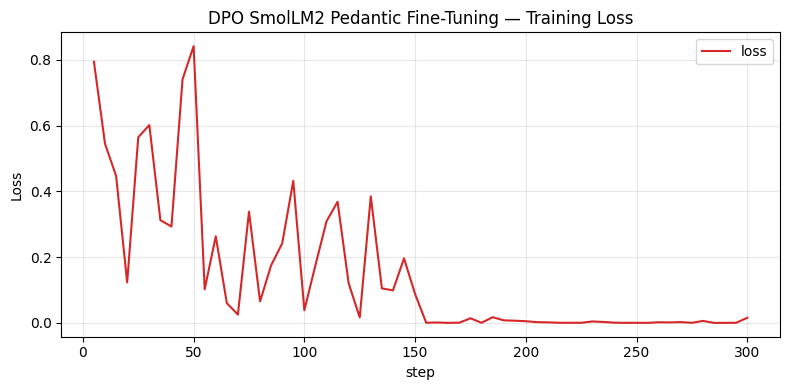

Saved: plots/DPO SmolLM2 Pedantic Fine-Tuning_loss.png and plots/DPO SmolLM2 Pedantic Fine-Tuning_loss.pdf


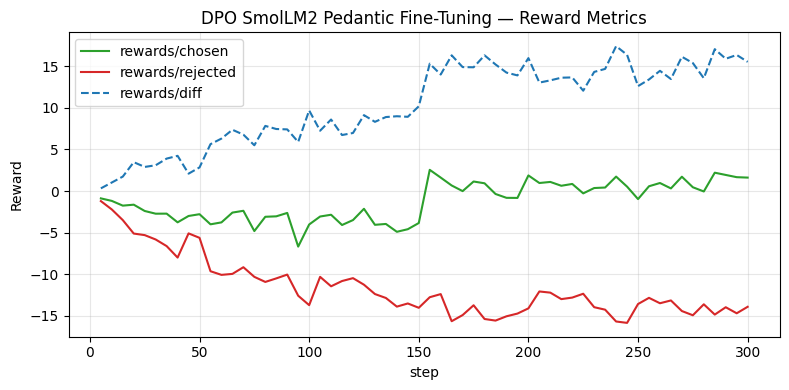

Saved: plots/DPO SmolLM2 Pedantic Fine-Tuning_reward.png and plots/DPO SmolLM2 Pedantic Fine-Tuning_reward.pdf


In [ ]:
metrics = dpo_trainer.evaluate()
dpo_trainer.log_metrics("eval", metrics)
dpo_trainer.save_metrics("eval", metrics)

# Plot relevant information such as LOSS/REWARDS over time
df = get_log_dataframe(dpo_trainer)
plot_training_metrics(df, run_name="DPO SmolLM2 Pedantic Fine-Tuning", save_dir="plots", smooth_alpha=1)


In [ ]:
dpo_tuned_model

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(49152, 576, padding_idx=2)
    (layers): ModuleList(
      (0-29): 30 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=576, out_features=576, bias=False)
          (k_proj): Linear(in_features=576, out_features=192, bias=False)
          (v_proj): Linear(in_features=576, out_features=192, bias=False)
          (o_proj): Linear(in_features=576, out_features=576, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=576, out_features=1536, bias=False)
          (up_proj): Linear(in_features=576, out_features=1536, bias=False)
          (down_proj): Linear(in_features=1536, out_features=576, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((576,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((576,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((576,), eps=1e-05)
    (r

In [ ]:
## Push to HuggingFace
repo_name = "SmolLM2-135M-Pedantic-DPO"
#reward_trainer.push_to_hub(repo_name)
dpo_tuned_model.push_to_hub(repo_name)

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...74fnext/model.safetensors:   0%|          | 12.0kB /  538MB            

CommitInfo(commit_url='https://huggingface.co/eZWALT/SmolLM2-135M-Pedantic-DPO/commit/65d5868af9ed5003a8362bb1fb759c4f26ecddc5', commit_message='Upload LlamaForCausalLM', commit_description='', oid='65d5868af9ed5003a8362bb1fb759c4f26ecddc5', pr_url=None, repo_url=RepoUrl('https://huggingface.co/eZWALT/SmolLM2-135M-Pedantic-DPO', endpoint='https://huggingface.co', repo_type='model', repo_id='eZWALT/SmolLM2-135M-Pedantic-DPO'), pr_revision=None, pr_num=None)

## 2.3 Group Relative Policy Optimization (GRPO)

**Group Relative Policy Optimization (GRPO)** is an advancement of PPO designed for **RLHF** fine-tuning with *grouped responses*.  
Instead of updating the policy using individual samples, GRPO compares multiple candidate responses to the same prompt and optimizes the policy based on their **relative rewards**.  
This allows GRPO to learn from pairwise or multiway preferences more efficiently, reducing variance and stabilizing updates.

Given a prompt $x$ and a group of $K$ sampled responses $\{y_1, y_2, \ldots, y_K\}$ with corresponding reward scores $\{r_1, r_2, \ldots, r_K\}$, the relative advantage for each response is computed as:

$$
A_i = r_i - \frac{1}{K} \sum_{j=1}^{K} r_j
$$

The policy is then updated to increase the likelihood of above-average responses and decrease that of below-average ones, using a PPO-style clipped objective:

$$
L^{\text{GRPO}}(\theta) =
\mathbb{E}_{x, i} \left[
\min \left(
r_i(\theta)\,A_i,\;
\text{clip}(r_i(\theta),\,1-\epsilon,\,1+\epsilon)\,A_i
\right)
\right],
\quad
r_i(\theta) = \frac{\pi_\theta(y_i|x)}{\pi_{\text{old}}(y_i|x)}
$$

Optionally, a KL penalty or entropy regularization term can be added to maintain similarity to the reference policy.  
By leveraging **relative ranking across a group** instead of absolute scalar rewards, GRPO provides a more stable and data-efficient training signal — aligning language models with human preferences while simplifying reward normalization and scaling.

Below see:
0. Reward functions defintions
1. Training
2. Architechture
3. Upload to HuggingFace


In [ ]:
# Optional heavy deps: use if available for better accuracy
try:
    import spacy
    _SPACY_AVAILABLE = True
    try:
        _NLP = spacy.load("en_core_web_sm")
    except Exception:
        _NLP = None
except Exception:
    _SPACY_AVAILABLE = False
    _NLP = None

try:
    from wordfreq import zipf_frequency
    _WORDFREQ_AVAILABLE = True
except Exception:
    _WORDFREQ_AVAILABLE = False

try:
    import textstat
    _TEXTSTAT_AVAILABLE = True
except Exception:
    _TEXTSTAT_AVAILABLE = False

# ----------------------
# Utilities
# ----------------------
def _to_batch(prompts, completions):
    single = False
    if isinstance(completions, str):
        completions = [completions]
        single = True
    if isinstance(prompts, str):
        prompts = [prompts] * len(completions)
    return prompts, completions, single

_word_re = re.compile(r"[A-Za-z']+")
_contractions_re = re.compile(
    r"\b(can't|won't|don't|didn't|shouldn't|couldn't|isn't|aren't|wasn't|weren't|it's|that's|i'm|i've|we're|they're|you're)\b",
    flags=re.I
)
_precision_adverbs = set(["actually", "technically", "precisely", "specifically", "notably", "strictly", "indeed", "explicitly"])

def _tokens(text: str) -> List[str]:
    return [t for t in _word_re.findall(text)]

def _avg_word_len(tokens: List[str]) -> float:
    return (sum(len(t) for t in tokens) / len(tokens)) if tokens else 0.0

def _ttr(tokens: List[str]) -> float:
    return (len(set(t.lower() for t in tokens)) / len(tokens)) if tokens else 0.0

def _avg_sentence_length(text: str) -> float:
    sents = re.split(r'[.!?]+\s+', text.strip())
    sents = [s for s in sents if s.strip()]
    if not sents:
        return 0.0
    return sum(len(_tokens(s)) for s in sents) / len(sents)

def _avg_zipf(tokens: List[str]) -> float:
    if not tokens:
        return 7.0
    if _WORDFREQ_AVAILABLE:
        vals = [zipf_frequency(t, "en") for t in tokens]
        return statistics.mean([max(-4.0, min(8.0, v)) for v in vals])
    # fallback estimate: shorter words -> higher zipf, long -> lower
    return statistics.mean([max(1.0, min(7.0, 7.0 - (len(t) - 3) * 0.4)) for t in tokens])

def _count_precision_adverbs(text: str) -> int:
    words = [w.lower() for w in _tokens(text)]
    return sum(1 for w in words if w in _precision_adverbs)

def _count_contractions(text: str) -> int:
    return len(_contractions_re.findall(text))

def _flesch_kincaid(text: str) -> float:
    if _TEXTSTAT_AVAILABLE:
        try:
            return float(textstat.flesch_kincaid_grade(text))
        except Exception:
            pass
    # fallback heuristic
    tokens = _tokens(text)
    avg_sent_len = _avg_sentence_length(text)
    if not tokens:
        return 0.0
    syll = []
    for w in tokens:
        wl = w.lower()
        # simple syllable estimator
        groups = re.findall(r'[aeiouy]+', wl)
        count = len(groups)
        if wl.endswith("e"):
            count = max(1, count - 1)
        syll.append(max(1, count))
    avg_syll = statistics.mean(syll) if syll else 1.0
    fk = 0.39 * avg_sent_len + 11.8 * avg_syll - 15.59
    return max(0.0, fk)

def _parse_depth_and_syntax(text: str) -> Dict[str, float]:
    """Try spaCy for parse depth and clauses, else heuristics."""
    if _SPACY_AVAILABLE and _NLP is not None:
        doc = _NLP(text)
        # depth: max children recursion depth
        def depth(tok):
            if not list(tok.children):
                return 0
            return 1 + max(depth(ch) for ch in tok.children)
        max_depth = max((depth(tok) for tok in doc), default=0)
        subordinate = sum(1 for tok in doc if tok.dep_ in ("advcl", "ccomp", "xcomp", "csubj", "csubjpass"))
        passive = sum(1 for tok in doc if tok.dep_ in ("nsubjpass", "auxpass"))
        return {"parse_depth": float(max_depth), "subordinate_clauses": float(subordinate), "passive_count": float(passive)}
    # heuristics
    avg_sent = _avg_sentence_length(text)
    parse_depth = avg_sent / 5.0
    subordinate = len(re.findall(r'\b(?:because|although|since|unless|whereas|while|though|after|before|until)\b', text, flags=re.I))
    passive = len(re.findall(r'\b(?:was|were|is|are|be|been)\s+[a-zA-Z]+ed\b', text.lower()))
    return {"parse_depth": parse_depth, "subordinate_clauses": float(subordinate), "passive_count": float(passive)}

# ----------------------
# Normalizers (smooth)
# ----------------------
def _sigmoid(x: float) -> float:
    return 1.0 / (1.0 + math.exp(-x))

def _normalize_pos(value: float, center: float, scale: float) -> float:
    return _sigmoid((value - center) / (scale + 1e-9))

def _normalize_neg(value: float, center: float, scale: float) -> float:
    return 1.0 - _sigmoid((value - center) / (scale + 1e-9))

# ----------------------
# Modular reward functions (each returns pedanticness in [0,1])
# ----------------------
def lexical_complexity_reward(prompts: Union[str, List[str]], completions: Union[str, List[str]], **kwargs) -> Union[float, List[float]]:
    """
    Lexical features: avg_word_len, TTR, avg_zipf (inverted).
    Higher => more pedantic.
    """
    _, completions, single = _to_batch(prompts, completions)
    out = []
    for c in completions:
        toks = _tokens(c)
        avg_wl = _avg_word_len(toks)
        ttr = _ttr(toks)
        avg_zipf = _avg_zipf(toks)
        # normalized: centers chosen to be mild for typical text
        s1 = _normalize_pos(avg_wl, center=5.0, scale=1.5)   # longer words => pedantic
        s2 = _normalize_pos(ttr, center=0.5, scale=0.12)     # more diversity => pedantic
        s3 = _normalize_neg(avg_zipf, center=4.5, scale=1.0) # lower zipf -> pedantic
        score = 0.45 * s1 + 0.35 * s2 + 0.20 * s3
        out.append(float(max(0.0, min(1.0, score))))
    return out[0] if single else out

def syntactic_complexity_reward(prompts: Union[str, List[str]], completions: Union[str, List[str]], **kwargs) -> Union[float, List[float]]:
    """
    Syntactic features: avg_sent_len, parse_depth, subordinate_clauses, passive_count
    """
    _, completions, single = _to_batch(prompts, completions)
    out = []
    for c in completions:
        feats = _parse_depth_and_syntax(c)
        asl = _avg_sentence_length(c)
        s_asl = _normalize_pos(asl, center=12.0, scale=6.0)
        s_depth = _normalize_pos(feats["parse_depth"], center=2.0, scale=1.5)
        s_sub = _normalize_pos(min(feats["subordinate_clauses"], 10.0), center=1.0, scale=2.0)
        s_pass = _normalize_pos(min(feats["passive_count"], 10.0), center=0.5, scale=1.0)
        score = 0.45 * s_asl + 0.30 * s_depth + 0.15 * s_sub + 0.10 * s_pass
        out.append(float(max(0.0, min(1.0, score))))
    return out[0] if single else out

def stylistic_precision_reward(prompts: Union[str, List[str]], completions: Union[str, List[str]], **kwargs) -> Union[float, List[float]]:
    """
    Stylistic markers: precision adverbs, contractions absence, Flesch-Kincaid readability
    Higher => more pedantic
    """
    _, completions, single = _to_batch(prompts, completions)
    out = []
    for c in completions:
        advs = _count_precision_adverbs(c)
        contr = _count_contractions(c)
        fk = _flesch_kincaid(c)
        s_advs = _normalize_pos(min(advs, 10.0), center=1.0, scale=2.0)
        s_contr = 1.0 - _normalize_pos(min(contr, 5.0), center=0.5, scale=1.0)  # fewer contractions -> pedantic
        s_fk = _normalize_pos(min(fk, 30.0), center=12.0, scale=4.0)
        score = 0.5 * s_fk + 0.3 * s_advs + 0.2 * s_contr
        out.append(float(max(0.0, min(1.0, score))))
    return out[0] if single else out

def concreteness_specificity_reward(prompts: Union[str, List[str]], completions: Union[str, List[str]], **kwargs) -> Union[float, List[float]]:
    """
    Reward presence of concrete references (numbers, dates, proper nouns).
    Note: high concreteness is not identical to pedanticness, but useful as a secondary signal.
    """
    _, completions, single = _to_batch(prompts, completions)
    out = []
    for c in completions:
        nums = len(re.findall(r'\b\d{1,4}\b', c))
        proper = len(re.findall(r'\b[A-Z][a-z]+(?:\s+[A-Z][a-z]+)*\b', c))
        concrete = nums + proper
        score = _sigmoid((concrete - 1.0) / 2.0)  # smooth growth
        out.append(float(max(0.0, min(1.0, score))))
    return out[0] if single else out

def length_reward(prompts: Union[str, List[str]], completions: Union[str, List[str]], **kwargs) -> Union[float, List[float]]:
    """
    Penalize extremely short completions (not pedantic) and reward moderate length.
    This avoids trivial short answers getting high pedantic score.
    """
    _, completions, single = _to_batch(prompts, completions)
    out = []
    for c in completions:
        nwords = len(_tokens(c))
        # prefer lengths around 50 words (center), reward grows to center then saturates
        score = _sigmoid((nwords - 50.0) / 20.0)
        out.append(float(max(0.0, min(1.0, score))))
    return out[0] if single else out

# ----------------------
# Keyword-focused reward functions (ADDED)
# ----------------------

# default pedantic keywords (precision, academic connectives, domainy nouns)
_DEFAULT_PEDANTIC_KEYWORDS = [
    # Core precision
    "actually", "technically", "precisely", "specifically", "notably", "strictly",
    "indeed", "explicitly", "formally", "canonically", "orthogonally", "axiomatically",

    # Academic connectives
    "therefore", "thus", "hence", "accordingly", "consequently", "furthermore",
    "moreover", "additionally", "nevertheless", "nonetheless", "notwithstanding",
    "wherein", "whereby", "herein", "thereof", "pursuant", "subsequently",

    # Observation & evidence
    "observed", "demonstrated", "illustrated", "exemplified", "corroborated",
    "validated", "substantiated", "quantified", "qualified", "characterized",

    # Academic concepts
    "hypothesis", "phenomenon", "mechanism", "methodology", "postulate",
    "theory", "framework", "paradigm", "heuristic", "algorithm",

    # Technical processes
    "implementation", "instantiation", "configuration", "parameterization",
    "initialization", "optimization", "validation", "verification", "specification",
    "orchestration", "containerization", "virtualization",

    # Formal adjectives
    "methodological", "systematic", "comprehensive", "exhaustive", "thorough",
    "meticulous", "scrupulous", "rigorous", "empirical", "analytical"
]


# common hedges/vague phrases to penalize lightly
_HEDGE_PHRASES = [
    # Uncertainty modals
    "might be", "could be", "would be", "should be", "can be", "may be",

    # Weak qualifiers
    "kind of", "sort of", "maybe", "perhaps", "probably", "possibly",
    "potentially", "arguably", "presumably", "supposedly",

    # Vague impressions
    "appears to", "seems to", "looks like", "gives the impression",
    "suggests that", "implies that", "hints at", "alludes to",

    # Personal uncertainty
    "I think", "I believe", "I feel", "I suppose", "I guess",
    "in my opinion", "from my perspective",

    # Approximation
    "more or less", "give or take", "thereabouts", "approximately",
    "roughly", "about", "around", "somewhat", "rather", "quite"
]

def _zipf_weight(token: str) -> float:
    """Return a rarity-based weight for a token (higher => rarer/stronger)."""
    if not token:
        return 1.0
    if _WORDFREQ_AVAILABLE:
        try:
            z = zipf_frequency(token, "en")  # typical range ~1..7-8 (higher = common)
            # invert: lower zipf (rarer) -> larger weight
            w = max(0.05, min(5.0, (8.0 - z) / 2.0))  # scale to ~0.05..5
            return float(w)
        except Exception:
            pass
    # fallback: base weighting by length (longer words -> rarer)
    return max(0.05, min(3.0, len(token) / 4.0))

def keyword_density_reward(prompts: Union[str, List[str]], completions: Union[str, List[str]],
                           keywords: Optional[List[str]] = None,
                           per_token: bool = True,
                           max_boost: float = 3.0,
                           smooth_center: float = 0.5,
                           **kwargs) -> Union[float, List[float]]:
    """
    Reward presence/density of pedantic/technical keywords.

    Args:
      keywords: optional override list of keywords (strings). If None uses default.
      per_token: if True normalize score by number of tokens (avoid long-text bias).
      max_boost: cap on aggregated keyword weight before sigmoid.
      smooth_center: center param for sigmoid mapping (controls sensitivity).

    Returns normalized score in [0,1], batch-safe.
    """
    _, completions, single = _to_batch(prompts, completions)
    kw_list = keywords or _DEFAULT_PEDANTIC_KEYWORDS
    kw_lower = [k.lower() for k in kw_list]

    out = []
    for c in completions:
        text = c.lower()
        tokens = _tokens(c)
        ntoks = max(1, len(tokens))

        # accumulate weighted matches (allow multi-token keywords via substring check)
        agg = 0.0
        for kw in kw_lower:
            # count non-overlapping occurrences (approx)
            count = text.count(kw)
            if count <= 0:
                continue
            # choose representative token to compute weight (first word of keyword)
            keytoken = kw.split()[0]
            w = _zipf_weight(keytoken)
            agg += count * w

        if per_token:
            # normalize by token count so longer outputs don't trivially win
            agg = agg / ntoks

        # cap and smooth
        agg_clipped = min(max_boost, agg)
        # map to [0,1] via sigmoid-ish transform centered at smooth_center * max_boost
        val = _sigmoid((agg_clipped - (smooth_center * max_boost)) / (max_boost * 0.25 + 1e-9))
        out.append(float(max(0.0, min(1.0, val))))
    return out[0] if single else out

def hedge_penalty_reward(prompts: Union[str, List[str]], completions: Union[str, List[str]],
                         hedges: Optional[List[str]] = None,
                         penalty_strength: float = 0.9,
                         **kwargs) -> Union[float, List[float]]:
    """
    Soft penalty for hedge/qualifying phrases. Returns 1.0 for no hedges, <1.0 when hedges present.
    penalty_strength: multiplier applied under presence (closer to 0 -> harsher).
    """
    _, completions, single = _to_batch(prompts, completions)
    hedge_list = hedges or _HEDGE_PHRASES
    hedge_lower = [h.lower() for h in hedge_list]

    out = []
    for c in completions:
        text = c.lower()
        # count occurrences with damping (diminishing returns)
        count = 0.0
        for h in hedge_lower:
            # simple substring count
            n = text.count(h)
            if n > 0:
                # diminishing returns: 1 - (1 / (1 + n))
                count += (1.0 - (1.0 / (1.0 + n)))
        # map count -> penalty factor in (0,1], using a smooth mapping
        # more hedges -> smaller factor
        factor = 1.0 / (1.0 + (count * (1.0 - penalty_strength) * 2.0))
        # clamp
        factor = float(max(0.0, min(1.0, factor)))
        out.append(factor)
    return out[0] if single else out

# ----------------------
# Utility: return list of functions for GRPO
# ----------------------
def get_grpo_reward_functions() -> List[Callable]:
    """
    Returns a list of reward functions to pass to GRPO (each returns [0,1]).
    Order: lexical, syntactic, stylistic, concreteness, length, keywords, hedge
    """
    return [
        lexical_complexity_reward,
        syntactic_complexity_reward,
        stylistic_precision_reward,
        concreteness_specificity_reward,
        length_reward,
        keyword_density_reward,   # new: promotes pedantic keywords
        hedge_penalty_reward,     # new: penalizes hedging softly
    ]

# ----------------------
# Combined wrapper (optional) to return a single scalar reward (weighted average).
# Use when the trainer expects a single reward function.
# ----------------------
def combined_pedantic_reward(prompts: Union[str, List[str]], completions: Union[str, List[str]],
                             weights: Optional[List[float]] = None, **kwargs) -> Union[float, List[float]]:
    """
    Compute weighted average of the modular pedantic rewards.
    weights: list of length equal to number of functions returned by get_grpo_reward_functions();
             defaults to a conservative vector emphasizing lexical+syntactic.
    """
    fns = get_grpo_reward_functions()
    if weights is None:
        # match the number of functions returned above
        weights = [0.18, 0.18, 0.15, 0.12, 0.12, 0.15, 0.10]
    # normalize weights
    s = float(sum(weights))
    if s == 0:
        weights = [1.0 / len(weights)] * len(weights)
    else:
        weights = [w / s for w in weights]

    # compute per-fn outputs (each could be scalar or list)
    # unify to list outputs
    _, completions, single = _to_batch(prompts, completions)
    per_fn_vals = [fn(prompts, completions, **kwargs) for fn in fns]
    # ensure each per_fn_vals[i] is list
    per_fn_lists = []
    for v in per_fn_vals:
        if isinstance(v, (int, float)):
            per_fn_lists.append([float(v)] * len(completions))
        else:
            per_fn_lists.append([float(x) for x in v])

    # weighted sum per item
    results = []
    for i in range(len(completions)):
        total = 0.0
        for j, lst in enumerate(per_fn_lists):
            total += weights[j] * lst[i]
        results.append(float(max(0.0, min(1.0, total))))
    return results[0] if single else results

# ----------------------
# Example usage
# ----------------------
# functions = get_grpo_reward_functions()
# # GRPO expects list of functions or a reward_fn; supply these fns directly if GRPO accepts a list.
# # Or use combined_pedantic_reward if a single callable is required:
# # reward_fn = lambda prompts, completions, **k: combined_pedantic_reward(prompts, completions, **k)


In [ ]:
from trl import GRPOConfig, GRPOTrainer

grpo_tuned_model = AutoModelForCausalLM.from_pretrained("HuggingFaceTB/SmolLM2-135M-Instruct")
processing_class = AutoTokenizer.from_pretrained("HuggingFaceTB/SmolLM2-135M-Instruct")

grpo_config = GRPOConfig(
    output_dir="GRPO-SmolLM2-135M-Pedantic",
    logging_steps=5,
    #use_cpu=True,
    seed=42,
    save_steps=100,
    # Training hyperparameters :)
    # LR, KL beta, batch size,
    num_train_epochs=1,
    #gradient_accumulation_steps=1,
    learning_rate=0.000025,
    beta=0.2, # Gentle KL coefficent
    per_device_train_batch_size=24,  # Small batch size for testing
    num_generations=6,  # Generate X completions per prompt
    generation_kwargs={
      "temperature": 0.9,       # 0.95 -> 1.1; higher = more creative but noisier
      "top_p": 0.975,            # nucleus cutoff (0.95-0.99 ok)
      "repetition_penalty": 1.08,
      "do_sample": True,
    },
)

grpo_trainer = GRPOTrainer(
    model=grpo_tuned_model,
    reward_funcs=get_grpo_reward_functions(),
    args=grpo_config,
    processing_class=processing_class,
    train_dataset=train_ds,
    eval_dataset=val_ds,
)
grpo_trainer.train()

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


<IPython.core.display.Javascript object>

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ezwalt (ezwalt-universitat-politecnica-de-catalunya) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: Detected [huggingface_hub.inference, openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai/


Step,Training Loss
5,-0.215700
10,-0.240700
15,-0.193000
20,-0.274400
25,-0.082800
30,-0.078200
35,-0.094800
40,-0.032000
45,-0.046400
50,-0.045900


TrainOutput(global_step=300, training_loss=-0.04799803332115213, metrics={'train_runtime': 9515.3635, 'train_samples_per_second': 0.126, 'train_steps_per_second': 0.032, 'total_flos': 0.0, 'train_loss': -0.04799803332115213})

In [ ]:
metrics = grpo_trainer.evaluate()
grpo_trainer.log_metrics("eval", metrics)
grpo_trainer.save_metrics("eval", metrics)

df = get_log_dataframe(grpo_trainer)
plot_training_metrics(df, run_name="GRPO SmolLM2 Pedantic Fine-Tuning", save_dir="plots", smooth_alpha=1)

Step,Training Loss
5,-0.048600
10,0.000000
15,0.000000
20,0.000000


KeyboardInterrupt: 

In [ ]:
## Push to HuggingFace
repo_name = "SmolLM2-135M-Pedantic-GRPO"
grpo_tuned_model.push_to_hub(repo_name)

# 3. **EXTRA** Supervised Fine-Tuning (SFT)

**Supervised Fine-Tuning (SFT)** is the foundational stage in the language model alignment pipeline where we directly train the model on high-quality demonstration data. Unlike reinforcement learning approaches that use reward signals, SFT employs standard supervised learning to teach the model desired behaviors through explicit examples.

Given a dataset of prompt-response pairs $\mathcal{D} = \{(x_1, y_1), (x_2, y_2), \ldots, (x_N, y_N)\}$, where $x_i$ represents a prompt and $y_i$ represents the desired response, the objective is to minimize the negative log-likelihood of the target responses: (i.e Token level Cross-Entropy loss, given our target variable is categorical)

$$
\mathcal{L}_{\text{SFT}}(\theta) = -\mathbb{E}_{(x,y) \sim \mathcal{D}} \left[ \sum_{t=1}^{T} \log \pi_\theta(y_t | x, y_{<t}) \right]
$$

where:
- $\pi_\theta$ is the policy (language model) being optimized
- $y_t$ is the token at position $t$ in the target response
- $y_{<t}$ represents all previous tokens in the response
- $T$ is the length of the response sequence

In our implementation, we leverage the **chosen responses** from our reward modeling dataset as the supervised training signals as we **assume they are high quality**, as they have been explicitly selected through human preference labeling.

SFT serves as a crucial warm-up phase before reinforcement learning, providing the model with a strong behavioral baseline and reducing the exploration space for subsequent policy optimization stages.  This is the actual previous step that we skipped and should have been a good idea to perform, but due to lack of data (1.5k examples) we are going to only consider this an experiment.

---

TLDR: We are going to create the **Pedantic Instruct** Model :)

In [4]:
from trl import SFTConfig, SFTTrainer
from transformers import AutoModelForCausalLM, AutoTokenizer
#from transformers import logging
#logging.set_verbosity_error()

# Load model and tokenizer (same as your GRPO setup)
sft_model = AutoModelForCausalLM.from_pretrained("HuggingFaceTB/SmolLM2-135M-Instruct")
tokenizer = AutoTokenizer.from_pretrained("HuggingFaceTB/SmolLM2-135M-Instruct")

# Add padding token if missing (IS THIS REALLY NEEDED?)
#if tokenizer.pad_token is None:
#    tokenizer.pad_token = tokenizer.eos_token

# Prepare SFT datasets using chosen responses
def format_sft_examples(example):
    """Format examples for SFT - combine prompt and chosen response"""
    return {
        "prompt": example["prompt"],
        "completion": example["chosen"]
    }

# Apply formatting to datasets
train_sft_dataset = dataset_dict["train"].map(format_sft_examples)
val_sft_dataset = dataset_dict["validation"].map(format_sft_examples)

# SFT Configuration
sft_config = SFTConfig(
    output_dir="SFT-SmolLM2-135M-Pedantic",
    logging_steps=5,
    seed=42,
    #save_steps=200,

    # Training hyperparameters
    num_train_epochs=4,
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=2,  # Effective batch size = 4 * 2 = 8

    # Optimization
    warmup_ratio=0.03,
    lr_scheduler_type="cosine_with_min_lr",
    lr_scheduler_kwargs={"min_lr_rate": 0.1},
    # Evaluation
    eval_strategy="steps",
    eval_steps=100,
)

print(f"Train dataset length: {len(train_sft_dataset)}")
print(f"Val dataset length: {len(val_sft_dataset)}")

# Check what the trainer will actually process
print(f"Per device batch size: {sft_config.per_device_train_batch_size}")
print(f"Gradient accumulation steps: {sft_config.gradient_accumulation_steps}")
print(f"Number of epochs: {sft_config.num_train_epochs}")

# Calculate expected steps
total_batch_size = sft_config.per_device_train_batch_size * sft_config.gradient_accumulation_steps
steps_per_epoch = len(train_sft_dataset) // total_batch_size
total_steps = steps_per_epoch * sft_config.num_train_epochs

print(f"Expected steps per epoch: {steps_per_epoch}")
print(f"Expected total steps: {total_steps}")

sft_trainer = SFTTrainer(
    model=sft_model,
    args=sft_config,
    train_dataset=train_sft_dataset,
    eval_dataset=val_sft_dataset,
    processing_class=tokenizer,

)
sft_trainer.train()

config.json:   0%|          | 0.00/861 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/269M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ezwalt (ezwalt-universitat-politecnica-de-catalunya) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
100,1.455700,1.500539,1.742651,196746.000000,0.617132
200,1.325500,1.417846,1.555055,398061.000000,0.626750
300,1.360900,1.382633,1.509399,590072.000000,0.629908
400,1.175700,1.373010,1.460960,786897.000000,0.629732
500,1.018300,1.370110,1.421558,985228.000000,0.629491
600,0.995100,1.368673,1.417229,1180144.000000,0.629405


TrainOutput(global_step=600, training_loss=1.2966983477274576, metrics={'train_runtime': 1277.3528, 'train_samples_per_second': 3.758, 'train_steps_per_second': 0.47, 'total_flos': 1221661752878592.0, 'train_loss': 1.2966983477274576, 'epoch': 4.0})

In [5]:
## Push to HuggingFace
repo_name = "SmolLM2-135M-Pedantic-SFT-Instruct"
sft_model.push_to_hub(repo_name)

README.md: 0.00B [00:00, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...5eh3jxw/model.safetensors:   0%|          | 12.0kB /  538MB            

CommitInfo(commit_url='https://huggingface.co/eZWALT/SmolLM2-135M-Pedantic-SFT-Instruct/commit/a4521150b870149d6d2b3e0dc2e67d82e8f302d4', commit_message='Upload LlamaForCausalLM', commit_description='', oid='a4521150b870149d6d2b3e0dc2e67d82e8f302d4', pr_url=None, repo_url=RepoUrl('https://huggingface.co/eZWALT/SmolLM2-135M-Pedantic-SFT-Instruct', endpoint='https://huggingface.co', repo_type='model', repo_id='eZWALT/SmolLM2-135M-Pedantic-SFT-Instruct'), pr_revision=None, pr_num=None)

## Next steps

As next steps for this experimentation notebook I would love to try out knowledge distillation processes and other more advanced RLHF algorithms, so I will leave it as a future work (If you feel brave enough i encourage you to upload a pull request :)